# 📊 State of Data Brazil 2024–2025  
## 🎯 Análise Estratégica para Talent Intelligence

Este notebook tem como objetivo:

- Construir benchmarks de mercado
- Identificar drivers de mobilidade
- Mapear maturidade técnica
- Analisar adoção de IA
- Criar segmentação de perfis
- Desenvolver modelo preditivo de intenção de saída

Base utilizada: State of Data Brazil 2024–2025

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

sns.set_style(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/state_of_data_2024.csv")

print("Shape:", df.shape)

Shape: (5217, 403)


In [44]:
df = df.drop(columns=["0.a_token", "0.d_data/hora_envio"], errors="ignore")
df = df.dropna(how="all")

df = df.copy()

print("Colunas:", len(df.columns))

Colunas: 401


In [45]:
if "2.n_planos_de_mudar_de_emprego_6m" in df.columns:
    df["wants_to_change"] = (
        df["2.n_planos_de_mudar_de_emprego_6m"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["sim", "talvez"])
        .astype(int)
    )
else:
    print("Coluna de mobilidade não encontrada.")

df = df.copy()

df["wants_to_change"].value_counts()

wants_to_change
0    5217
Name: count, dtype: int64

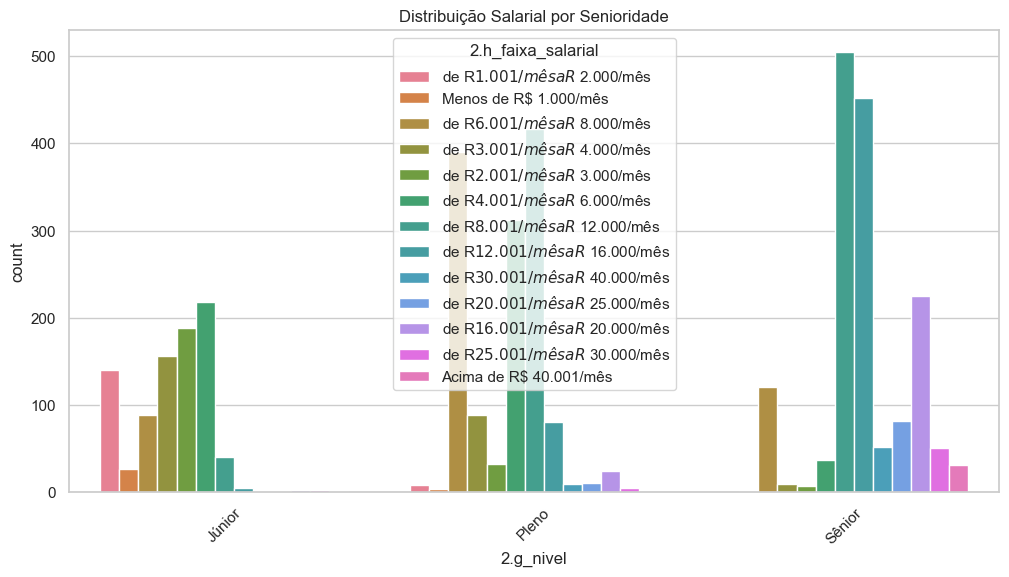

In [46]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="2.g_nivel", hue="2.h_faixa_salarial")
plt.xticks(rotation=45)
plt.title("Distribuição Salarial por Senioridade")
plt.show()

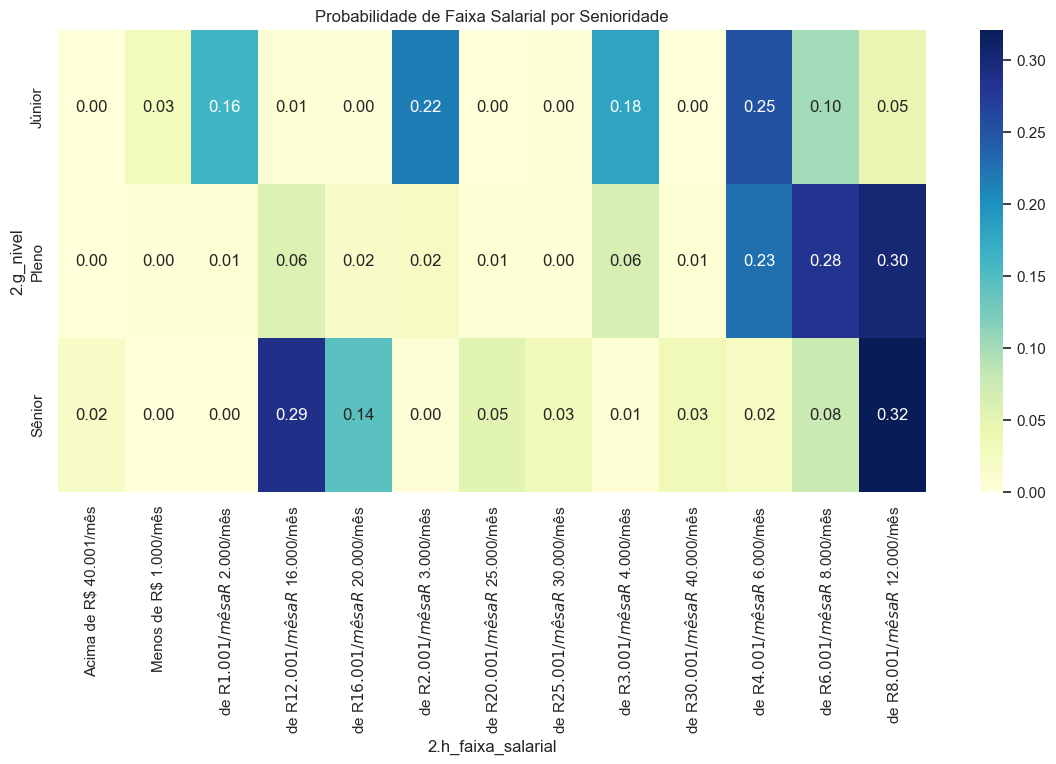

In [47]:
salary_heatmap = pd.crosstab(
    df["2.g_nivel"],
    df["2.h_faixa_salarial"],
    normalize="index"
)

plt.figure(figsize=(14,6))
sns.heatmap(salary_heatmap, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Probabilidade de Faixa Salarial por Senioridade")
plt.show()

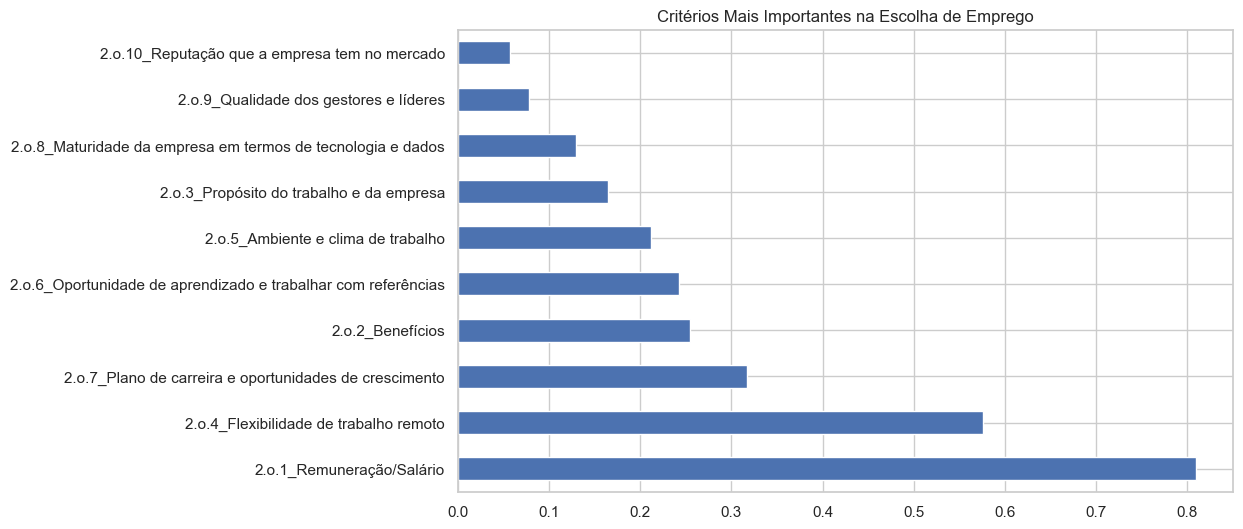

In [48]:
criterios = [col for col in df.columns if col.startswith("2.o.")]

criterios_mean = df[criterios].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
criterios_mean.plot(kind="barh")
plt.title("Critérios Mais Importantes na Escolha de Emprego")
plt.show()

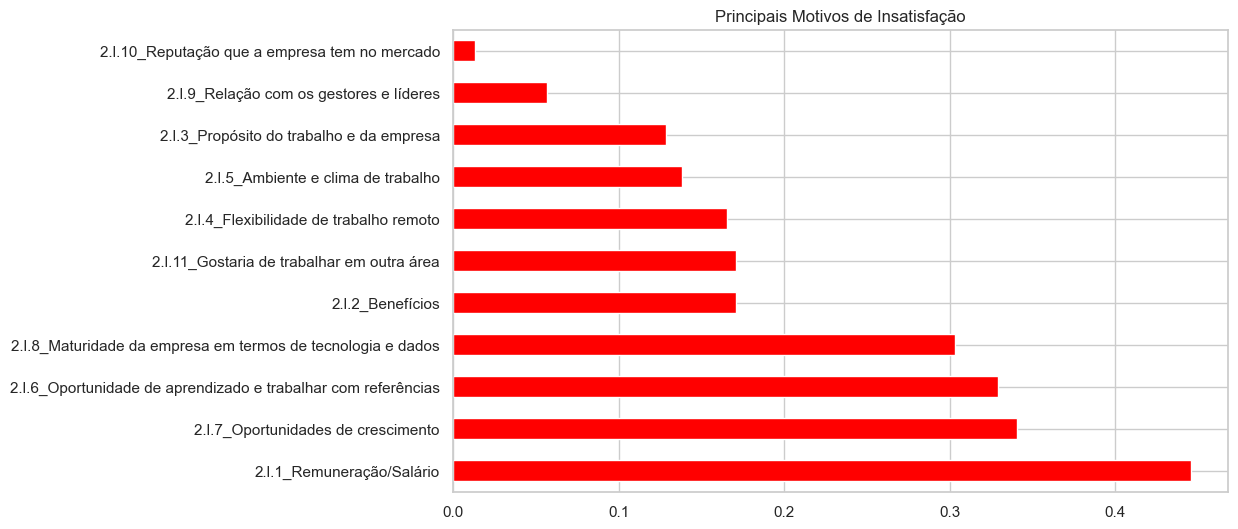

In [49]:
insatisfacao = [col for col in df.columns if col.startswith("2.l.")]

insatisfacao_mean = df[insatisfacao].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
insatisfacao_mean.plot(kind="barh", color="red")
plt.title("Principais Motivos de Insatisfação")
plt.show()

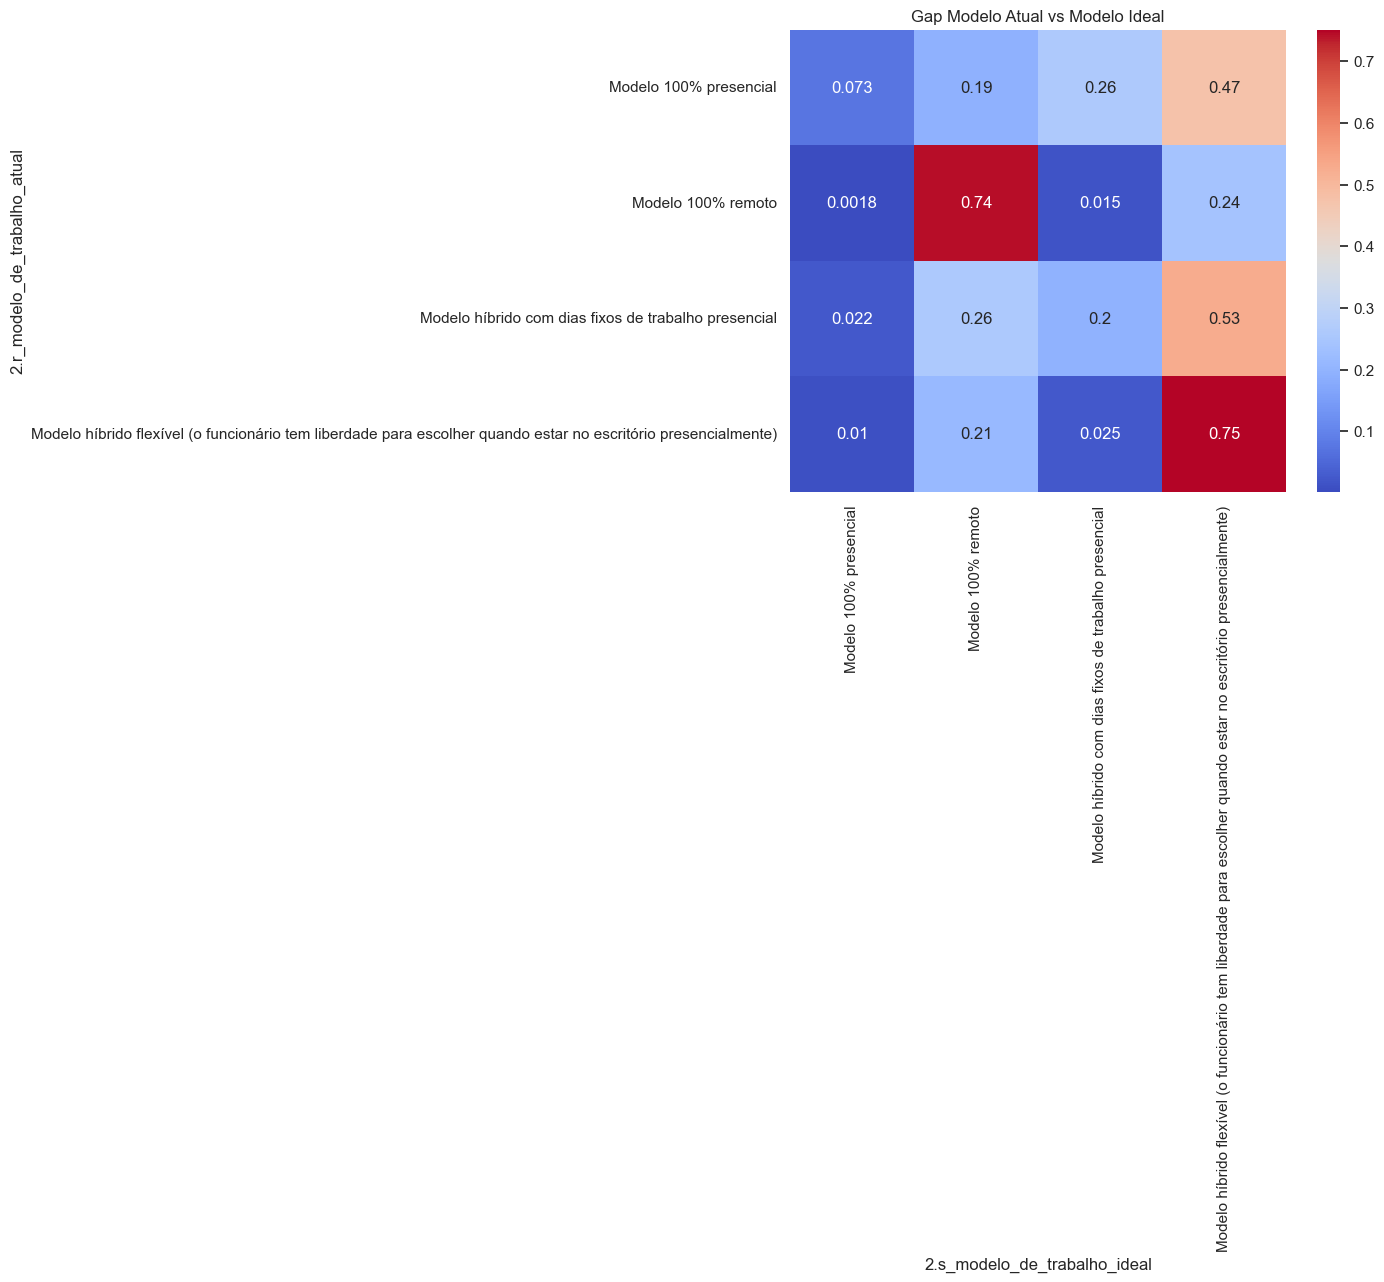

In [50]:
cross_model = pd.crosstab(
    df["2.r_modelo_de_trabalho_atual"],
    df["2.s_modelo_de_trabalho_ideal"],
    normalize="index"
)

plt.figure(figsize=(8,6))
sns.heatmap(cross_model, annot=True, cmap="coolwarm")
plt.title("Gap Modelo Atual vs Modelo Ideal")
plt.show()

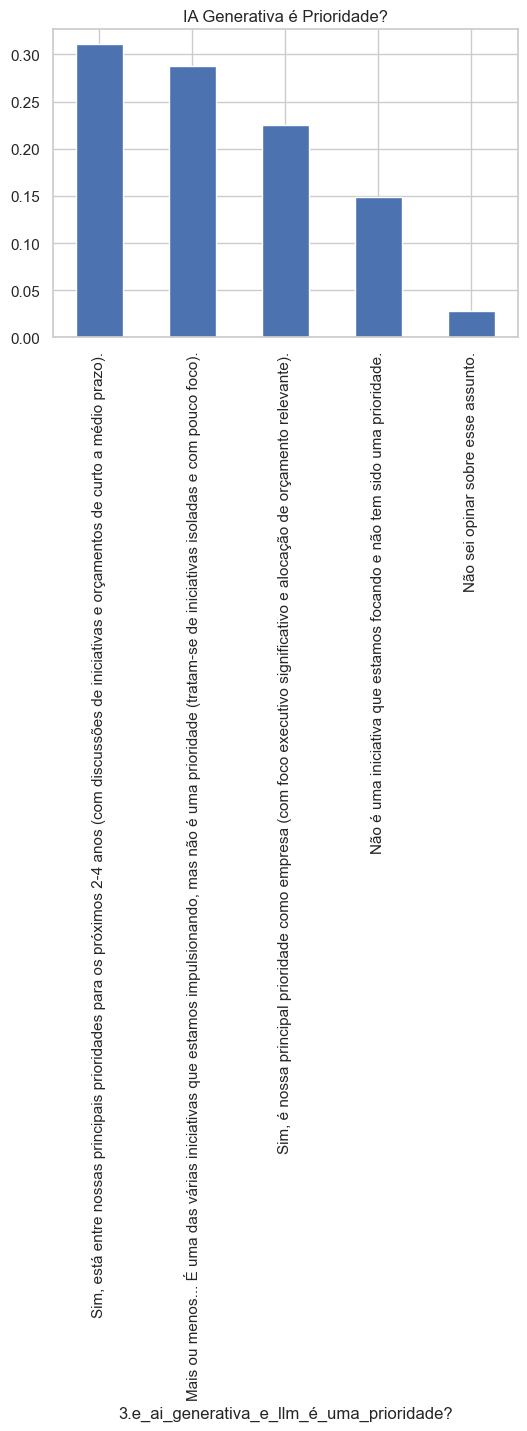

In [51]:
plt.figure(figsize=(6,4))
df["3.e_ai_generativa_e_llm_é_uma_prioridade?"].value_counts(normalize=True).plot(kind="bar")
plt.title("IA Generativa é Prioridade?")
plt.show()

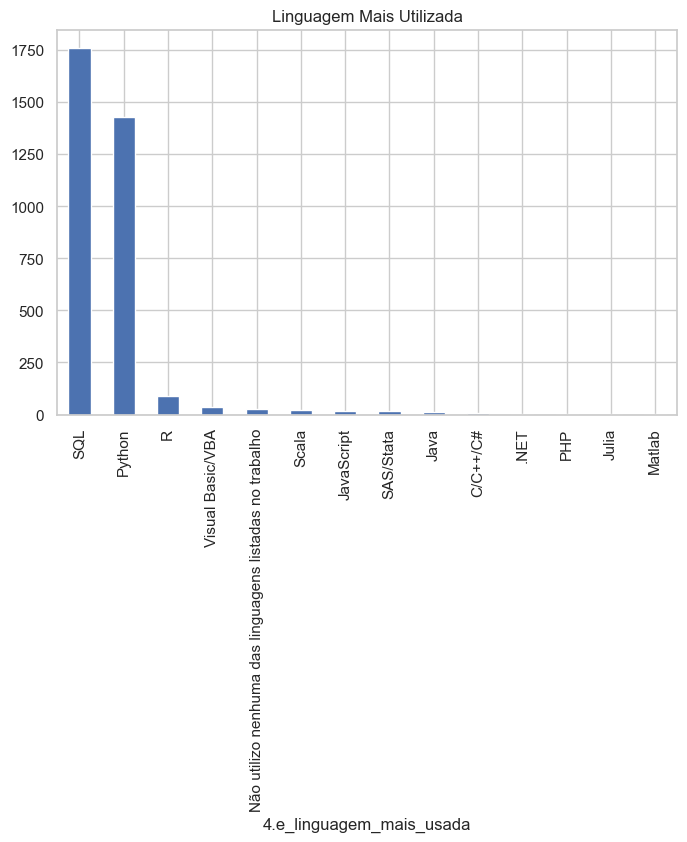

In [54]:
plt.figure(figsize=(8,5))
df["4.e_linguagem_mais_usada"].value_counts().plot(kind="bar")
plt.title("Linguagem Mais Utilizada")
plt.show()

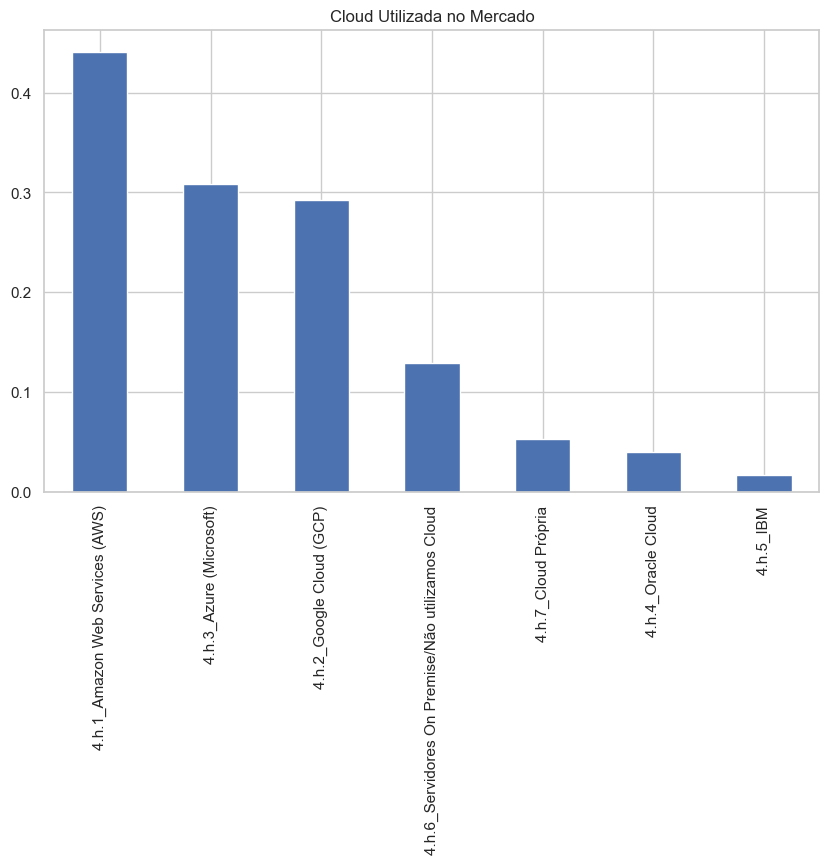

In [55]:
cloud_cols = [col for col in df.columns if col.startswith("4.h.")]
cloud_usage = df[cloud_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
cloud_usage.plot(kind="bar")
plt.title("Cloud Utilizada no Mercado")
plt.show()

In [56]:
features = [
    "2.k_satisfeito_atualmente",
    "2.o.1_Remuneração/Salário",
    "2.o.4_Flexibilidade de trabalho remoto",
    "2.o.7_Plano de carreira e oportunidades de crescimento",
]

features = [f for f in features if f in df.columns]

X = df[features].fillna(0)
y = df["wants_to_change"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1566

    accuracy                           1.00      1566
   macro avg       1.00      1.00      1.00      1566
weighted avg       1.00      1.00      1.00      1566



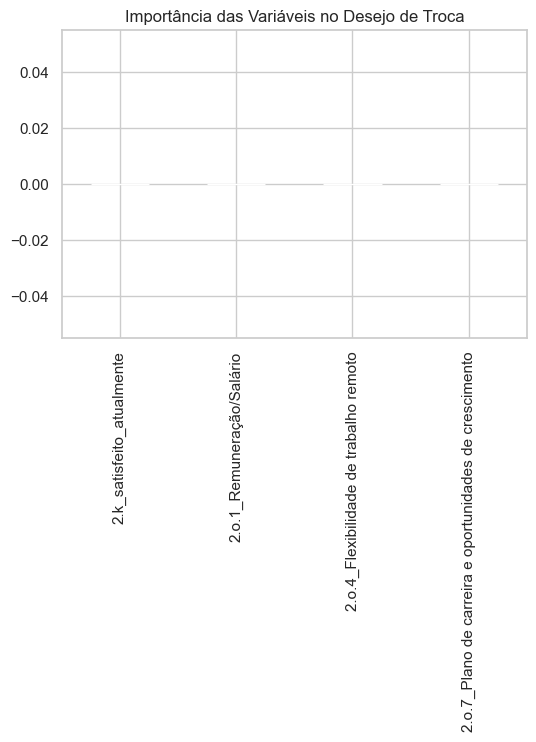

In [57]:
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.title("Importância das Variáveis no Desejo de Troca")
plt.show()

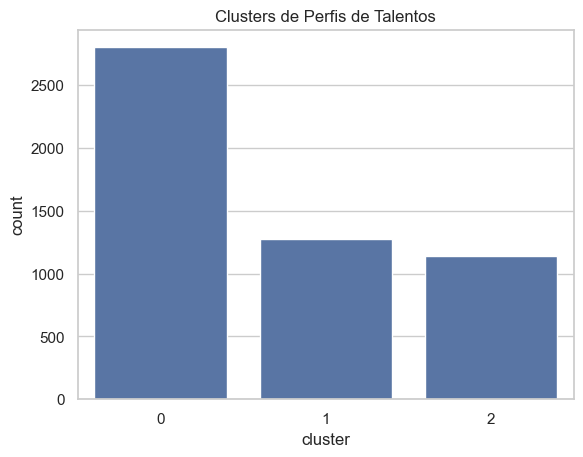

In [58]:
cluster_features = df[features].fillna(0)

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled)

sns.countplot(x="cluster", data=df)
plt.title("Clusters de Perfis de Talentos")
plt.show()

In [59]:
df.groupby("cluster")[features].mean()

,2.k_satisfeito_atualmente,2.o.1_Remuneração/Salário,2.o.4_Flexibilidade de trabalho remoto,2.o.7_Plano de carreira e oportunidades de crescimento
cluster,,,,
0,0.706995,1.0,0.687366,0.000000
1,0.654013,0.0,0.456616,0.438178
2,0.660228,1.0,0.401229,1.000000
